# E8 — Speculative Decoding on a Toy Model

> **Enrichment — not examinable.** The official unit content is in `examples/`. This lesson exists to connect what you just learned to how the field works in 2026.

## 📚 Learning Objectives

By completing this notebook, you will:
- Build two character n-gram language models — a slow accurate **target** and a fast weak **draft** — over the same vocabulary, from real text on disk
- Implement **draft-and-verify decoding** with the rejection rule `accept x with probability min(1, p(x)/q(x))`, including the residual resampling step that makes it correct
- Cut the number of calls to the expensive model by roughly **3×** for the same 1,500 characters, and measure the exact figure
- Verify with 200,000 trials and a χ² test that the output distribution is **unchanged** — and see what happens to that distribution when you skip the verification step
- Derive the expected characters-per-call formula yourself and check it against the measured acceptance rate

## 🔗 Where this fits

**Builds on:** Unit 3 lesson 06 *"GPT-Style Text Generation"* — Step 2 defines a generation function that loops one token at a time, and Step 4 compares temperatures. That loop, one expensive model call per token, is precisely the cost this notebook attacks. Unit 3 lesson 08 *"RNN, LSTM and GRU for Text Generation"* — Step 1 builds a character↔index mapping and generates character by character; our two models are character models for exactly that reason.

Most directly: Unit 3 lesson 04 *"Transformer and Attention"* closes with a **State of the field (2026)** box that names two techniques as "worth knowing by the time you leave this unit" — paged attention, and "**speculative decoding**, which gets more than one token per call to the expensive model with the output distribution left provably unchanged (arXiv 2211.17192)". **This notebook is the second half of that sentence, built and measured.**

**Used later in:** Course 10 (AIAT 124) — Unit 2 lesson 01 *"Text Generation with Autoregressive (GPT-style) Models"*, where generation cost becomes a design constraint. Course 11 (AIAT 125) — Unit 2 *"Versioning and Serving"*, where "how many model calls per response" turns into a bill.

## 🌍 Why this matters: decoding is the part that costs money

Training a language model is a one-time cost. **Generating** with it is a cost you pay on every request, forever, and it has an awkward shape: to produce token *t* you must already have produced token *t−1*. The loop is strictly sequential, and each step is one full forward pass through the whole model.

In November 2022 Yaniv Leviathan, Matan Kalman and Yossi Matias published *Fast Inference from Transformers via Speculative Decoding* ([arXiv:2211.17192](https://arxiv.org/abs/2211.17192), ICML 2023 Oral). Their headline measurement, on **T5-XXL**, was a **2×–3× speed-up over the standard T5X implementation** — with the output distribution left exactly unchanged, and with no retraining and no architectural change to the model.

**That is the named, checkable case.** The idea is almost embarrassingly simple. Let a small cheap model *guess* the next few tokens. Then call the big model **once** to score all of those guesses at the same time — it can, because the guessed tokens are already known, so there is nothing sequential left to wait for. Keep the guesses the big model agrees with; throw away the rest and repair the first disagreement. Do the repair with the right formula and the tokens you emit are drawn from *exactly* the big model's distribution.

**Why this works at all** is a hardware fact worth carrying: generating one token from a large model moves far more bytes of weights than it performs arithmetic, so the hardware sits idle waiting for memory. Scoring five positions instead of one moves the *same* weights and uses compute that was going to waste. Modern serving stacks are built around this observation (Kwon et al., [arXiv:2309.06180](https://arxiv.org/abs/2309.06180); Jiang et al., [arXiv:2607.08057](https://arxiv.org/abs/2607.08057)).

**What goes wrong without this lesson.** The obvious "speed-up" is to just use the small model. That is not an optimisation, it is a different product — and in Part 3 you will measure exactly how different, on the same context, in total variation distance. The whole point of speculative decoding is that it is **not** an approximation.

## 📥 Inputs & 📤 Outputs

**Inputs:** the first 400,000 characters of this repository's own course markdown — the quizzes, projects, case studies and assessment briefs, real prose written for students and already on disk (the README index pages are skipped; they are navigation, not writing). No downloads, no API keys, no network, no GPU, no pretrained weights. The models are counted, not trained. `np.random` appears only where randomness *is* the mechanism: drawing a token from a distribution, and drawing the uniform variate the accept/reject test compares against.

**Outputs:** two character n-gram models over a shared 31-symbol vocabulary; a side-by-side view of where they agree and disagree; a plain autoregressive baseline with its call count; the same length of text produced by draft-and-verify with its call count; a 200,000-trial three-arm distribution test with total variation distances and χ² p-values; a chart of the three empirical distributions; a sweep over the draft block size γ compared against a formula you derive; a sweep over draft model strength; and a cost model that explains why γ stays small in practice.

## Part 1: Two models, one vocabulary

A speculative decoder needs a **draft** model and a **target** model that speak the same alphabet. Ours are the same kind of object at two sizes: character n-gram models with interpolated back-off.

An order-*k* model counts, for every *k*-character context seen in the corpus, which character came next. To turn counts into a distribution that is never zero, we interpolate from the bottom up: start with the uniform distribution, blend in the order-0 (letter frequency) counts, then order-1, and so on up to order *k*. A context nobody has ever seen simply stops the chain early and falls back to shorter context — no crash, no zero probability. That last property is not cosmetic: the rejection rule in Part 2 divides by `q(x)`, so `q` must be strictly positive everywhere.

- **Target** — order 7. Seven characters of context. Slow and good.
- **Draft** — order 4. Four characters of context. Fast and rough.

The draft is *literally a truncation of the target's own count tables*, which makes the shared-vocabulary requirement automatic. In production that requirement is a real constraint: a draft model with a different tokenizer cannot be used at all.

In [1]:
# WHAT: read the repository's course markdown, reduce it to a small character alphabet, and count
#       every context of length 0..7 together with the characters that followed it.
# WHY:  the whole lesson needs two models that differ in quality but agree on the alphabet. Counting
#       n-grams from real text gives us that in half a second, with no training and no downloads.
import re
import collections
import time
from pathlib import Path
import numpy as np


def find_repo_root(start: Path) -> Path:
    """Walk up until we find the folder that holds the twelve course directories."""
    for parent in [start, *start.parents]:
        if (parent / "Course 01").is_dir() and (parent / "Course 12").is_dir():
            return parent
    raise RuntimeError(f"Could not locate the repository root starting from {start}")


REPO = find_repo_root(Path.cwd())
# Skip the README index pages: they are navigation, not prose, and they change whenever the course
# structure is edited. Quizzes, projects, case studies and assessment briefs are the real writing,
# and a character model trained on real writing is the whole point.
paths = [p for p in sorted(REPO.glob("Course */**/*.md")) if p.name != "README.md"]
if len(paths) < 150:
    raise RuntimeError(f"Expected 150+ non-README markdown files under Course */, found {len(paths)}.")

raw = "\n".join(p.read_text(encoding="utf-8") for p in paths)
raw = re.sub(r"```.*?```", " ", raw, flags=re.S)     # drop fenced code: it is not prose
raw = re.sub(r"`[^`]*`", " ", raw)                   # and inline code spans
raw = re.sub(r"https?://\S+", " ", raw)              # URLs are noise for a character model
raw = raw.lower()
raw = re.sub(r"[^a-z ,.'\-]", " ", raw)              # a small alphabet keeps every distribution cheap
CORPUS = re.sub(r"\s+", " ", raw).strip()[:400_000]

VOCAB = sorted(set(CORPUS))
V = len(VOCAB)
STOI = {ch: i for i, ch in enumerate(VOCAB)}
print(f"{len(paths)} markdown files -> {len(CORPUS):,} training characters")
print(f"vocabulary: {V} symbols -> {''.join(VOCAB)!r}")

K_MAX = 7


def build_tables(text: str, k_max: int):
    """tables[k][context] = (character indices seen after that context, their counts)."""
    tables = []
    for k in range(k_max + 1):
        counts = collections.defaultdict(collections.Counter)
        if k == 0:
            counts[""] = collections.Counter(text)          # plain letter frequencies
        else:
            for i in range(k, len(text)):
                counts[text[i - k:i]][text[i]] += 1
        tables.append({ctx: (np.array([STOI[ch] for ch in cnt], dtype=np.int32),
                             np.array(list(cnt.values()), dtype=np.float64))
                       for ctx, cnt in counts.items()})
    return tables


t0 = time.time()
TABLES = build_tables(CORPUS, K_MAX)
print(f"\nbuilt orders 0..{K_MAX} in {time.time() - t0:.1f}s")
for k in (1, 2, 4, 7):
    print(f"  order {k}: {len(TABLES[k]):>7,} distinct contexts")

200 markdown files -> 400,000 training characters
vocabulary: 31 symbols -> " ',-.abcdefghijklmnopqrstuvwxyz"



built orders 0..7 in 0.6s
  order 1:      31 distinct contexts
  order 2:     648 distinct contexts
  order 4:  17,959 distinct contexts
  order 7: 116,634 distinct contexts


In [2]:
# WHAT: turn the count tables into probability distributions, then look at the target and the draft
#       side by side on four real contexts.
# WHY:  speculative decoding lives or dies on how often the two models agree. Before measuring that
#       over thousands of characters, look at four cases by eye so the number later means something.
TARGET = TABLES                       # the expensive model: 7 characters of context
DRAFT_ORDER = 4
DRAFT = TABLES[:DRAFT_ORDER + 1]      # the cheap model: the same counts, truncated to 4 characters


def dist(model, context: str) -> np.ndarray:
    """Interpolated back-off distribution over the next character. Strictly positive everywhere."""
    d = np.full(V, 1.0 / V)                                   # start from uniform: nothing is impossible
    for k in range(len(model)):
        entry = model[k].get(context[len(context) - k:] if k > 0 else "")
        if entry is None:
            break                                             # unseen context: stop climbing the orders
        idx, cnt = entry
        blended = d.copy()                                    # the shorter-context estimate is the prior
        blended[idx] += cnt                                   # longer-context counts dominate it
        d = blended / blended.sum()
    return d


def top(d, n=4):
    return "  ".join(f"{VOCAB[i]!r}:{d[i]:.3f}" for i in np.argsort(-d)[:n])


PROBES = ["neural netw", "evaluate the m", "the model is tr", "a confusion m", "gradient desc"]

print(f"target model: order {K_MAX}    draft model: order {DRAFT_ORDER}    shared vocabulary: {V} symbols\n")
disagreement = {}
for ctx in PROBES:
    p, q = dist(TARGET, ctx), dist(DRAFT, ctx)
    disagreement[ctx] = 0.5 * float(np.abs(p - q).sum())
    print(f"context {ctx!r}   total variation |p-q| = {disagreement[ctx]:.3f}")
    print(f"    target : {top(p)}")
    print(f"    draft  : {top(q)}\n")

# Pick the hardest case for the verifier, rather than naming one and hoping. Part 3 tests there.
WORST = max(disagreement, key=disagreement.get)
EASIEST = min(disagreement, key=disagreement.get)
print(f"easiest for the draft : {EASIEST!r}  (|p-q| = {disagreement[EASIEST]:.3f}) - a free guess")
print(f"hardest for the draft : {WORST!r}  (|p-q| = {disagreement[WORST]:.3f}) - Part 3 tests here")

target model: order 7    draft model: order 4    shared vocabulary: 31 symbols

context 'neural netw'   total variation |p-q| = 0.004
    target : 'o':1.000  'e':0.000  'i':0.000  'h':0.000
    draft  : 'o':0.996  'e':0.004  'i':0.000  'h':0.000

context 'evaluate the m'   total variation |p-q| = 0.106
    target : 'a':0.464  'o':0.253  'i':0.141  'e':0.107
    draft  : 'a':0.458  'o':0.349  'e':0.099  'i':0.078

context 'the model is tr'   total variation |p-q| = 0.181
    target : 'a':0.668  'u':0.165  'y':0.164  'e':0.002
    draft  : 'a':0.745  'u':0.105  'e':0.085  'y':0.043

context 'a confusion m'   total variation |p-q| = 0.556
    target : 'a':0.947  'o':0.049  'e':0.003  'i':0.001
    draft  : 'a':0.391  'e':0.311  'o':0.160  'l':0.073

context 'gradient desc'   total variation |p-q| = 0.563
    target : 'e':0.926  'r':0.074  'a':0.000  'u':0.000
    draft  : 'r':0.637  'e':0.362  'a':0.000  'u':0.000

easiest for the draft : 'neural netw'  (|p-q| = 0.004) - a free guess
hard

Read the total-variation numbers before going on, because they are the whole problem in miniature. Two patterns appear. Where four characters of context are already enough to pin the answer down, both models put almost all their mass on the same character and the draft's guess is **free and correct** — that is where the speed-up comes from. Where the *seventh* character is what decides — a technical term this corpus only ever completes one way — the draft is looking at a much more ambiguous prefix, proposes confidently, and proposes wrongly. That is what the verification step exists to catch, and the cell picked out the sharpest example of it for Part 3.

## Part 2: One expensive call per token — the baseline

Standard sampling is the loop from lesson 06: ask the model for a distribution, draw one character, append it, repeat. `n` characters cost `n` target calls. There is no way around that within the loop, because the model cannot score position *t* until position *t−1* exists.

In [3]:
# WHAT: the ordinary autoregressive sampler - one target-model call per character produced.
# WHY:  this is the baseline every speedup claim is measured against, and the call counter is the
#       only quantity that matters. Count it explicitly rather than trusting a stopwatch.
SEED_TEXT = "machine learning models are "
N_TOKENS = 1500


def autoregressive(n_tokens, seed=0, context=SEED_TEXT):
    """Sample n_tokens characters from the target model, counting every call to it."""
    rng = np.random.default_rng(seed)          # sampling IS the mechanism here, so the RNG is the point
    out, calls = [], 0
    while len(out) < n_tokens:
        p = dist(TARGET, context)
        calls += 1                             # one expensive call bought exactly one character
        ch = VOCAB[int(rng.choice(V, p=p))]
        out.append(ch)
        context += ch
    return "".join(out), calls


t0 = time.time()
base_text, base_calls = autoregressive(N_TOKENS)
print(f"plain sampling: {N_TOKENS} characters, {base_calls} target calls "
      f"({N_TOKENS / base_calls:.2f} characters per call), {time.time() - t0:.2f}s")
print(f"\n{base_text[:280]!r}")

plain sampling: 1500 characters, 1500 target calls (1.00 characters per call), 0.04s

'large. ensure sufficient, what data is available on kaggle - maximum elementation functions, transportation --- q when a notebook inference between gradients the key differentiation - pca good creative prediction represent - a complete episode return. td error code min, max, etc.'


Now the speculative version. Each round does four things:

1. **Draft.** Run the cheap model γ times in a row to guess γ characters.
2. **Verify.** Call the expensive model **once** to score all γ+1 positions. In a real Transformer this is one forward pass: the drafted tokens are already known, so they can all be fed in at the same time — the same reason training is parallel over positions and generation is not. In our toy the "call" is a loop over γ+1 contexts, so we count it as **one call** and say plainly that the count is what transfers, not the timing.
3. **Accept or repair.** Walk left to right. Accept drafted character `x` with probability `min(1, p(x)/q(x))`. At the first rejection, throw away everything to its right and emit one character drawn from the **residual** distribution `norm(max(0, p − q))`.
4. **Bonus.** If all γ were accepted, the target's distribution at position γ+1 has already been computed, so take a free character from it.

Step 3 is the entire correctness argument. A character the draft over-proposes (`q` bigger than `p`) gets rejected in proportion to the excess; the residual distribution puts back exactly the mass the draft was missing. The two effects cancel, and what comes out is distributed as `p`. Part 3 tests that claim rather than asserting it.

In [4]:
# WHAT: draft-and-verify decoding with rejection sampling (Leviathan et al., arXiv:2211.17192).
# WHY:  read the accept test and the residual line together - they are the only two places where the
#       algorithm differs from "just trust the small model", and they are why the output is exact.
def speculative(n_tokens, gamma, draft=DRAFT, seed=0, context=SEED_TEXT):
    """Return (text, number of target calls, acceptance rate)."""
    rng = np.random.default_rng(seed)
    out, calls, evaluated, accepted = [], 0, 0, 0

    def draw(d):
        return int(rng.choice(V, p=d))

    while len(out) < n_tokens:
        # --- 1. DRAFT: gamma cheap calls, run sequentially because the draft is autoregressive too
        ctx = context
        drafted, q_dists = [], []
        for _ in range(gamma):
            q = dist(draft, ctx)
            x = draw(q)
            q_dists.append(q)
            drafted.append(x)
            ctx += VOCAB[x]

        # --- 2. VERIFY: ONE target call scoring all gamma+1 positions. The drafted characters are
        #        already known, so a real Transformer computes these in a single parallel forward pass.
        p_dists = [dist(TARGET, context + "".join(VOCAB[y] for y in drafted[:i]))
                   for i in range(gamma + 1)]
        calls += 1

        # --- 3. ACCEPT or REPAIR, left to right
        emitted, rejected = [], False
        for i in range(gamma):
            evaluated += 1
            if rng.random() <= p_dists[i][drafted[i]] / q_dists[i][drafted[i]]:
                emitted.append(drafted[i])                       # the target agrees often enough
                accepted += 1
            else:
                residual = np.maximum(p_dists[i] - q_dists[i], 0.0)   # the mass the draft under-weighted
                residual /= residual.sum()
                emitted.append(draw(residual))                   # this repair is what keeps p exact
                rejected = True
                break                                            # everything to the right is now invalid

        # --- 4. BONUS: all gamma accepted means p at position gamma+1 is already computed - free token
        if not rejected:
            emitted.append(draw(p_dists[gamma]))

        out.extend(VOCAB[y] for y in emitted)
        context += "".join(VOCAB[y] for y in emitted)

    return "".join(out[:n_tokens]), calls, accepted / evaluated


GAMMA = 4
t0 = time.time()
spec_text, spec_calls, alpha = speculative(N_TOKENS, GAMMA)
print(f"speculative (gamma={GAMMA}): {N_TOKENS} characters, {spec_calls} target calls "
      f"({N_TOKENS / spec_calls:.2f} characters per call), {time.time() - t0:.2f}s")
print(f"acceptance rate alpha = {alpha:.3f}")
print(f"\n  plain sampling : {base_calls} target calls")
print(f"  speculative    : {spec_calls} target calls")
print(f"  -> {base_calls / spec_calls:.2f}x fewer calls to the expensive model "
      f"for the same {N_TOKENS} characters\n")
print(f"{spec_text[:280]!r}")

speculative (gamma=4): 1500 characters, 497 target calls (3.02 characters per call), 0.07s
acceptance rate alpha = 0.747

  plain sampling : 1500 target calls
  speculative    : 497 target calls
  -> 3.02x fewer calls to the expensive model for the same 1500 characters

'simple uses less in . provides pre-trained in the following stanford ml concepts question points submit all groups - may have complete project from unit examples with often better estimator use optimal numbered students with. it computation, most sections unclear. --- part shows '


**About three times fewer calls to the expensive model** — the exact count is printed above. The two passages of text are different, and they are *supposed* to be different — they are two independent draws from the same distribution, not two copies of one answer. The claim is never "identical text". It is "identical distribution", and that is a claim you have to test.

## Part 3: Is the output distribution really unchanged?

Fix one context and ask for a single character 200,000 times, three ways:

- **Sample from the target** — the ground truth. One expensive call per character.
- **Draft and verify** — one draft call, one accept/reject test, and a residual draw when it fails.
- **Draft only, no verification** — the "optimisation" people reach for first.

We do not choose the context by hand: the previous cell selected the probe where the two models disagree most, and this part tests there. If the verification step is going to fail anywhere, it fails at the context where the draft is most confidently wrong.

Two measurements. **Total variation distance** to the target distribution, which is the largest probability error you could construct from the sample. And a **χ² goodness-of-fit p-value** against the target's own probabilities — a large p-value means the sample is indistinguishable from the target, a p-value of 0 means it is not the same distribution.

In [5]:
# WHAT: run the one-character experiment 200,000 times per arm, vectorised, and compare each arm's
#       empirical distribution against the target's exact probabilities.
# WHY:  "provably unchanged" is a claim about a distribution, so it needs a distributional test, not a
#       side-by-side glance at two paragraphs of generated text.
from scipy import stats

CTX = WORST                     # the hardest of the probe contexts, chosen by the cell above
N_TRIALS = 200_000
p = dist(TARGET, CTX)
q = dist(DRAFT, CTX)
rng = np.random.default_rng(11)

arm_direct = rng.choice(V, size=N_TRIALS, p=p)          # ground truth: sample straight from the target
arm_draft = rng.choice(V, size=N_TRIALS, p=q)           # the shortcut: just use the small model

# The speculative arm, one step of the algorithm above, done 200,000 times at once.
x = rng.choice(V, size=N_TRIALS, p=q)                   # the draft's proposal
u = rng.random(N_TRIALS)                                # the uniform variate of the accept test
keep = u <= np.minimum(1.0, p[x] / q[x])                # accept with probability min(1, p/q)
residual = np.maximum(p - q, 0.0)
residual /= residual.sum()
arm_spec = x.copy()
arm_spec[~keep] = rng.choice(V, size=int((~keep).sum()), p=residual)   # repair every rejection

print(f"context {CTX!r}")
print(f"  target says  : {top(p)}")
print(f"  draft says   : {top(q)}")
print(f"  theoretical acceptance probability here: "
      f"{float(np.sum(q * np.minimum(1.0, p / q))):.4f}   measured: {keep.mean():.4f}\n")

expected = N_TRIALS * p
big = expected >= 25                                    # chi-square needs cells with real mass;
                                                        # the rest are lumped into one bucket
print(f"  {'arm':<26} {'target calls':>13} {'TV distance to p':>18} {'chi2 p-value':>13}")
for name, arm, cost in [("sample from target", arm_direct, "1 per token"),
                        ("draft + verify", arm_spec, "1 per block"),
                        ("draft only (no verify)", arm_draft, "0")]:
    counts = np.bincount(arm, minlength=V)
    tv = 0.5 * np.abs(counts / N_TRIALS - p).sum()
    obs = np.append(counts[big], counts[~big].sum()).astype(float)
    exp = np.append(expected[big], expected[~big].sum())
    obs *= exp.sum() / obs.sum()                        # make the two totals match exactly
    print(f"  {name:<26} {cost:>13} {tv:>18.5f} {stats.chisquare(obs, exp).pvalue:>13.4f}")

context 'gradient desc'
  target says  : 'e':0.926  'r':0.074  'a':0.000  'u':0.000
  draft says   : 'r':0.637  'e':0.362  'a':0.000  'u':0.000
  theoretical acceptance probability here: 0.4368   measured: 0.4365

  arm                         target calls   TV distance to p  chi2 p-value
  sample from target           1 per token            0.00008        0.9907
  draft + verify               1 per block            0.00073        0.4644
  draft only (no verify)                 0            0.56361        0.0000


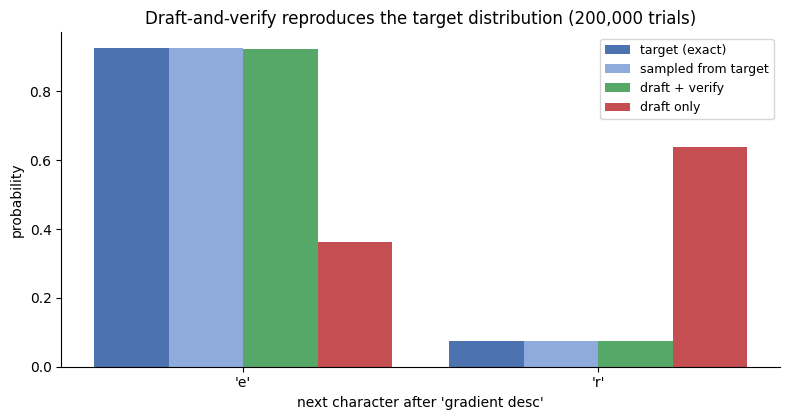

The first three bars in each group are the same height to within sampling noise. The fourth
is a different distribution entirely - and it is the one you get by 'just using the small model'.


In [6]:
# WHAT: plot the three empirical distributions against the target's exact probabilities.
# WHY:  the table above is the evidence; this is the picture that makes it impossible to misread.
import matplotlib.pyplot as plt     # the notebook's inline backend renders the figure below the cell

# Only the characters either model gives real mass to: empty groups would waste the width.
show = [i for i in np.argsort(-(p + q)) if max(p[i], q[i]) > 0.01][:6]
labels = [repr(VOCAB[i]) for i in show]
series = [("target (exact)", p[show], "#4C72B0"),
          ("sampled from target", np.bincount(arm_direct, minlength=V)[show] / N_TRIALS, "#8FAADC"),
          ("draft + verify", np.bincount(arm_spec, minlength=V)[show] / N_TRIALS, "#55A868"),
          ("draft only", np.bincount(arm_draft, minlength=V)[show] / N_TRIALS, "#C44E52")]

xpos = np.arange(len(show))
width = 0.21
fig, ax = plt.subplots(figsize=(8.0, 4.3))
for j, (name, vals, col) in enumerate(series):
    ax.bar(xpos + (j - 1.5) * width, vals, width, label=name, color=col)
ax.set_xticks(xpos, labels)
ax.set_xlabel(f"next character after {CTX!r}")
ax.set_ylabel("probability")
ax.set_title(f"Draft-and-verify reproduces the target distribution ({N_TRIALS:,} trials)")
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

print("The first three bars in each group are the same height to within sampling noise. The fourth")
print("is a different distribution entirely - and it is the one you get by 'just using the small model'.")

## 💬 Discuss

1. The accept test is `min(1, p(x)/q(x))`, so a draft that is **over**-confident about its favourite character gets rejected often, while one that is **under**-confident is accepted almost always. If you were training a draft model on purpose, which of those two errors would you rather it made — and what does your answer imply about the temperature you would decode the draft at?
2. Both the "sample from target" arm and the "draft + verify" arm return a large χ² p-value, and in Part 4 the measured α is different in every row even though the pairing of models never changed. A colleague concludes that whichever arm has the larger p-value is the "more correct" sampler, and that the γ with the highest characters-per-call is the best γ. Explain what is wrong with each conclusion, and name the cheapest change to this notebook that would settle both.
3. This whole scheme only pays off because the target model can score γ+1 positions for roughly the price of one. Name a decoding setting where that stops being true, and say what would happen to the measured speed-up there.

## Part 4: Where the speed-up comes from, and why γ stays small

The acceptance rate α is the only quantity that matters, and you can predict the rest from it with a paragraph of algebra.

In one round, the probability that exactly *j* of the drafted characters are accepted and the (*j*+1)-th is rejected is `α^j (1 − α)`, and that round emits *j* + 1 characters (the *j* accepted ones plus the repair). If all γ are accepted — probability `α^γ` — the round emits γ + 1 characters, thanks to the bonus token. Summing:

$$\mathbb{E}[\text{characters per round}] \;=\; \sum_{j=0}^{\gamma-1}\alpha^{j}(1-\alpha)(j+1) \;+\; \alpha^{\gamma}(\gamma+1) \;=\; \sum_{j=0}^{\gamma}\alpha^{j} \;=\; \frac{1-\alpha^{\gamma+1}}{1-\alpha}$$

Each round is one target call, so that expression *is* characters per target call. Two consequences fall straight out and both are worth internalising: the sum is bounded above by `1/(1 − α)` no matter how large you make γ, and it is driven entirely by α — which is a property of **how well the two models agree**, not of either model on its own.

Let us check the formula against the machine. One warning before you read the table: α is *estimated* from a single 1,500-character run, so it wobbles by a few points between rows, and the characters-per-call column wobbles with it. Compare each row's measurement against the formula **using that row's own α** — which is what the last column does.

In [7]:
# WHAT: sweep the draft block size gamma, and compare the measured characters-per-call against the
#       formula derived above using the acceptance rate measured in the same run.
# WHY:  a derivation you cannot check is folklore. This cell is the check, and it is also how you would
#       size gamma for a real system: measure alpha once, then predict instead of guessing.
gamma_rows = []
print(" gamma | target calls | characters/call | alpha | formula (1-a^(g+1))/(1-a)")
for g in [1, 2, 3, 4, 5, 6, 8]:
    _, calls, a = speculative(N_TOKENS, g)
    predicted = (1 - a ** (g + 1)) / (1 - a)
    gamma_rows.append({"gamma": g, "calls": calls, "per_call": N_TOKENS / calls,
                       "alpha": a, "predicted": predicted})
    print(f" {g:5d} | {calls:12d} | {N_TOKENS / calls:15.2f} | {a:.3f} | {predicted:24.2f}")

print(f"\nCeiling at this acceptance rate: 1/(1-alpha) = "
      f"{1 / (1 - gamma_rows[3]['alpha']):.2f} characters per call, however large gamma gets.")

 gamma | target calls | characters/call | alpha | formula (1-a^(g+1))/(1-a)


     1 |          864 |            1.74 | 0.737 |                     1.74
     2 |          668 |            2.25 | 0.725 |                     2.25
     3 |          583 |            2.57 | 0.716 |                     2.60


     4 |          497 |            3.02 | 0.747 |                     3.04


     5 |          462 |            3.25 | 0.750 |                     3.29
     6 |          471 |            3.18 | 0.720 |                     3.21


     8 |          426 |            3.52 | 0.738 |                     3.56

Ceiling at this acceptance rate: 1/(1-alpha) = 3.96 characters per call, however large gamma gets.


In [8]:
# WHAT: sweep the draft model's order from 1 to 5, holding gamma fixed.
# WHY:  this isolates the real currency of speculative decoding. Nothing about the target changed;
#       only how well the draft agrees with it - and the speed-up moves with that alone.
order_rows = []
print(" draft order | contexts |  alpha | characters/call | speed-up vs plain sampling")
for k in [1, 2, 3, 4, 5]:
    _, calls, a = speculative(N_TOKENS, GAMMA, draft=TABLES[:k + 1])
    order_rows.append({"order": k, "calls": calls, "alpha": a,
                       "per_call": N_TOKENS / calls, "speedup": base_calls / calls})
    print(f" {k:11d} | {len(TABLES[k]):8,} | {a:.3f} | {N_TOKENS / calls:15.2f} | "
          f"{base_calls / calls:24.2f}x")

 draft order | contexts |  alpha | characters/call | speed-up vs plain sampling
           1 |       31 | 0.261 |            1.35 |                     1.35x


           2 |      648 | 0.433 |            1.74 |                     1.74x
           3 |    4,798 | 0.601 |            2.31 |                     2.31x
           4 |   17,959 | 0.747 |            3.02 |                     3.02x


           5 |   44,984 | 0.849 |            3.68 |                     3.68x


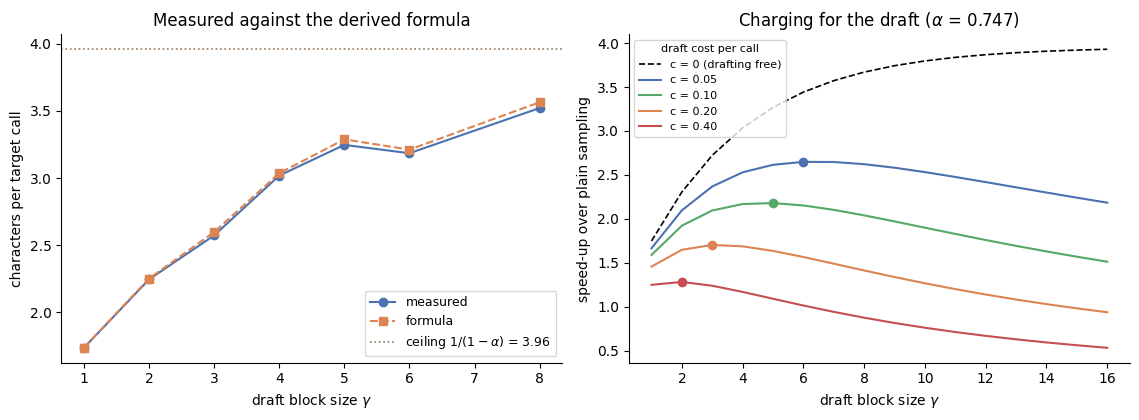

Left: the formula tracks the measurement row by row, so alpha really is sufficient to predict
characters-per-call. Right: as soon as a draft call costs anything, the curve has a peak.

  draft call costs 5% of a target call -> best gamma = 6, speed-up 2.65x
  draft call costs 10% of a target call -> best gamma = 5, speed-up 2.18x
  draft call costs 20% of a target call -> best gamma = 3, speed-up 1.70x
  draft call costs 40% of a target call -> best gamma = 2, speed-up 1.28x

Every one of those optima is a single-digit block. That is the honest reason draft blocks are
short: not a rule of thumb, but the point where paying for one more guess stops paying back.

This right-hand panel is arithmetic from the measured alpha under a stated cost assumption,
not a timing of this notebook: both of our models are dictionary lookups.


In [9]:
# WHAT: two panels - measured vs predicted characters per call against gamma, and acceptance rate
#       against draft strength - plus a cost model that explains why production gamma is small.
# WHY:  characters-per-call rises with gamma forever, but the drafting is not free. Once you charge
#       for it, the curve has a maximum, and that maximum is the number a serving team actually picks.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.3))

g_vals = [r["gamma"] for r in gamma_rows]
ax1.plot(g_vals, [r["per_call"] for r in gamma_rows], "o-", color="#4C72B0", label="measured")
ax1.plot(g_vals, [r["predicted"] for r in gamma_rows], "s--", color="#DD8452", label="formula")
a_ref = gamma_rows[3]["alpha"]
ax1.axhline(1 / (1 - a_ref), color="#937860", ls=":", lw=1.2,
            label=fr"ceiling $1/(1-\alpha)$ = {1 / (1 - a_ref):.2f}")
ax1.set_xlabel(r"draft block size $\gamma$"); ax1.set_ylabel("characters per target call")
ax1.set_title("Measured against the derived formula")
ax1.legend(fontsize=9); ax1.spines[["top", "right"]].set_visible(False)

# The cost model: one round costs 1 target call plus gamma draft calls, where a draft call costs c
# target calls. Speed-up over plain sampling = E[characters] / (1 + gamma*c).
gg = np.arange(1, 17)
ax2.plot(gg, (1 - a_ref ** (gg + 1)) / (1 - a_ref), "k--", lw=1.2, label="c = 0 (drafting free)")
best_gamma = {}
for cost, col in [(0.05, "#4C72B0"), (0.10, "#55A868"), (0.20, "#DD8452"), (0.40, "#C44E52")]:
    speed = (1 - a_ref ** (gg + 1)) / ((1 - a_ref) * (1 + gg * cost))
    ax2.plot(gg, speed, "-", color=col, label=f"c = {cost:.2f}")
    ax2.plot(gg[np.argmax(speed)], speed.max(), "o", color=col)
    best_gamma[cost] = (int(gg[np.argmax(speed)]), float(speed.max()))
ax2.set_xlabel(r"draft block size $\gamma$"); ax2.set_ylabel("speed-up over plain sampling")
ax2.set_title(fr"Charging for the draft ($\alpha$ = {a_ref:.3f})")
ax2.legend(fontsize=8, title="draft cost per call", title_fontsize=8)
ax2.spines[["top", "right"]].set_visible(False)

plt.tight_layout(); plt.show()

print("Left: the formula tracks the measurement row by row, so alpha really is sufficient to predict")
print("characters-per-call. Right: as soon as a draft call costs anything, the curve has a peak.\n")
for cost, (g_best, s_best) in best_gamma.items():
    print(f"  draft call costs {cost:.0%} of a target call -> best gamma = {g_best}, "
          f"speed-up {s_best:.2f}x")
print("\nEvery one of those optima is a single-digit block. That is the honest reason draft blocks are")
print("short: not a rule of thumb, but the point where paying for one more guess stops paying back.")
print("\nThis right-hand panel is arithmetic from the measured alpha under a stated cost assumption,")
print("not a timing of this notebook: both of our models are dictionary lookups.")

## ✅ Summary

**What you actually did here** (every number computed live above):

- Built a target (order 7) and a draft (order 4) character model from 400,000 characters of this repository's real prose, over a shared 31-symbol vocabulary
- Probed five real contexts and found both extremes: one where four characters of context already settle the answer and the two models agree almost exactly, and one where the seventh character is what decides and the draft is confidently wrong — the cell picks out both, and Part 3 tests at the harder one
- Generated 1,500 characters with plain sampling — exactly 1,500 target calls — and the same 1,500 with draft-and-verify at γ = 4, for **about a third as many target calls**
- Measured the acceptance rate α and confirmed the derived formula `(1 − α^(γ+1))/(1 − α)` row by row across γ = 1…8
- Ran 200,000 trials at the context where the two models disagree most: the χ² test **could not distinguish** draft-and-verify from the target's own distribution, exactly as it could not distinguish direct sampling from it — while the draft alone sat hundreds of times further away in total variation, with a χ² p-value of zero
- Showed that the entire speed-up is bought by agreement: an order-1 draft barely improves on plain sampling, while an order-5 draft more than triples the characters per target call

**The one sentence to keep:** speculative decoding is not an approximation — it trades a *cheap wrong guess plus a correction* for an *expensive right answer*, and the correction is exactly the piece that makes the output distribution identical.

**Where this goes next:** replace the two n-gram tables with a 1B-parameter draft and a 70B target, replace "one target call" with one batched forward pass over the drafted block, and the algorithm is unchanged — the 2026 research direction is making the draft cheaper and wider, for instance by drafting a whole block in parallel with a diffusion model instead of sequentially ([arXiv:2602.06036](https://arxiv.org/abs/2602.06036)).

## ⚠️ Where this breaks

**Our call counts are exact; our timings are meaningless.** Both models here are dictionary lookups, so the draft is not meaningfully cheaper than the target and a "target call" that scores γ+1 positions costs γ+1 lookups. Nothing about wall-clock time in this notebook transfers. What transfers is the **count** — and the reason the count is the right thing to measure is a hardware property of large models we asserted in the introduction and did not verify here: decoding is memory-bandwidth-bound, so scoring several positions costs about the same as scoring one (Kwon et al., [arXiv:2309.06180](https://arxiv.org/abs/2309.06180)).

**That property has limits, and the right-hand chart is a model, not a measurement.** The cost curve assumes a draft call costs a fixed fraction *c* of a target call and that verifying γ+1 positions costs exactly one. Both assumptions weaken as γ grows and the verification pass stops being memory-bound. Measure `c` and the shape of your own verification cost before trusting the peak.

**A server that is already busy has less to give.** The spare capacity speculative decoding exploits is compute the hardware was wasting while it waited for weights. A serving stack that is already saturating its compute — for example by batching many requests together — has less of that spare capacity, so the benefit shrinks. That is a reasoned consequence of the memory-bound argument above, not something this notebook measured.

**Vocabularies must match, exactly.** Our draft is a truncation of the target's own tables, so `p` and `q` are automatically defined over the same 31 symbols. Two real models with different tokenizers cannot be paired at all without a translation layer, and that constraint eliminates most otherwise-attractive draft candidates.

**α is a property of a pairing on a domain, not a constant — and ours is a noisy estimate of it.** We measured it for an order-4 draft against an order-7 target, on this corpus, from one seed context. The γ sweep re-measures the same pairing seven times and returns a spread of several percentage points, purely from sampling. Any two rows of that table differing by less than that spread are not telling you anything. Change the corpus, the prompt, or the sampling temperature and it moves — which means the speed-up you can promise a customer has to be measured on their traffic, not quoted from a paper.

**And the guarantee is about the distribution, not about your output.** Draft-and-verify does not reproduce the text plain sampling would have produced; it produces a fresh sample from the same distribution. If a user compares two runs and sees different answers, that is correct behaviour, and no amount of pointing at a χ² p-value will make it feel that way. Systems that need reproducible output need a fixed seed and a fixed batch composition — a serving problem, not a decoding one.

## 📚 References

Getting more than one token per expensive call, and the memory story that makes it work:

1. Leviathan, Y., Kalman, M., & Matias, Y. (2022). *Fast Inference from Transformers via Speculative Decoding*. ICML 2023 Oral. [arXiv:2211.17192](https://arxiv.org/abs/2211.17192) — the algorithm implemented in Part 2, the rejection rule in Part 3, and the source of the T5-XXL "2X-3X acceleration compared to the standard T5X implementation" figure quoted at the top.
2. Kwon, W., Li, Z., Zhuang, S., Sheng, Y., Zheng, L., Yu, C. H., Gonzalez, J. E., Zhang, H., & Stoica, I. (2023). *Efficient Memory Management for Large Language Model Serving with PagedAttention*. SOSP 2023. [arXiv:2309.06180](https://arxiv.org/abs/2309.06180) — vLLM's paged KV cache; why generative serving is a memory-management discipline and not an arithmetic one.
3. Nguyen, C. V., Shen, X., Aponte, R., Xia, Y., Basu, S., Hu, Z., Chen, J., Parmar, M., et al. (2024). *A Survey of Small Language Models*. [arXiv:2410.20011](https://arxiv.org/abs/2410.20011) — the design space your draft model comes from; useful when the question changes from "which draft?" to "which small model?".
4. Jiang, J., Yang, P., Zhang, R., & Liu, F. (2026). *Towards Efficient Large Language Model Serving: A Survey on System-Aware KV Cache Optimization*. [arXiv:2607.08057](https://arxiv.org/abs/2607.08057) — the current consolidation of KV-cache work across execution, placement and representation.
5. Chen, J., Liang, Y., & Liu, Z. (2026). *DFlash: Block Diffusion for Flash Speculative Decoding*. [arXiv:2602.06036](https://arxiv.org/abs/2602.06036) — drafting a whole block in parallel instead of sequentially; where the sequential draft loop in our Part 2 is heading.

**Data source:** the non-README `.md` files under `Course 01/` … `Course 12/` of this repository — quizzes, projects, case studies and assessment briefs; real course prose, used unmodified apart from the lower-casing and character filtering shown in the first code cell.